In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder, StandardScaler
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    mean_absolute_error, r2_score,
    classification_report, roc_auc_score, confusion_matrix, ConfusionMatrixDisplay,
)
from sklearn.linear_model import LassoCV
import shap

import statsmodels.formula.api as smf
import statsmodels.api as sm
from scipy import stats

from scripts.preprocess import load_preprocessed_data

## Feature Engineering

Two parallel targets from the same feature matrix:
- **Regression** → `profit` (€): where is value created or destroyed?
- **Classification** → `is_loss` (profit < 0): will this task lose money?

### Design Decisions
1. `rework_ratio` (rework_hours / hours_spent) captures efficiency erosion, normalised across task sizes. Capped at 1.0 for the 67 ambiguous rows where rework > hours.
2. `billable_hours` dropped because collinear with `hours_spent` and downstream of pricing.
3. `revenue`, `cost` excluded because it's a direct components of `profit` (leakage).

In [65]:
df = load_preprocessed_data("data/ai_productivity_dataset_final.csv")

In [66]:
REG_TARGET = "profit"
CLF_TARGET = "is_loss"

In [67]:
# columns excluded from features (leakage, identifiers, collinear, or target-derived)
LEAK_COLS = ["revenue", "cost", "billable_hours", "is_loss", "profit"]
ID_COLS = ["task_id", "client", "project_id", "created_by", "jira_ticket"]
DATE_COLS = ["created_at", "delivered_at", "updated_at"]
META_COLS = ["task_status", "workflow_stage", "content_version"]
REDUNDANT_COLS = ["ai_assisted", "legacy_ai_flag", "rework_hours"]   # absorbed by ai_usage_pct / rework_ratio
DROP_COLS = LEAK_COLS + ID_COLS + DATE_COLS + META_COLS + REDUNDANT_COLS

ORDINAL_COLS = ["seniority", "deadline_pressure", "client_tier"]
ORDINAL_CATEGORIES = [
    ["junior", "mid", "senior"],
    ["low", "medium", "high"],
    ["low", "mid", "high"],
]

NOMINAL_COLS = ["pricing_model", "task_type", "team"]

In [68]:
def add_rework_ratio(df):
    """Fraction of effort spent on rework, capped at 1.0 for ambiguous rows."""
    df = df.copy()
    df["rework_ratio"] = (df["rework_hours"] / df["hours_spent"]).clip(upper=1.0)
    return df


def select_features(df):
    """Drop leakage / id / metadata columns, return feature-only DataFrame."""
    return df.drop(columns=[c for c in DROP_COLS if c in df.columns])


def identify_column_groups(X):
    """Split columns into passthrough-numeric, ordinal, and nominal groups."""
    passthrough = [c for c in X.columns if c not in ORDINAL_COLS + NOMINAL_COLS]
    return passthrough, ORDINAL_COLS, NOMINAL_COLS


def build_preprocessor(passthrough_cols, ordinal_cols, nominal_cols):
    """ColumnTransformer: passthrough numerics, ordinal-encode ordered cats, one-hot nominals."""
    return ColumnTransformer(
        transformers=[
            ("num", "passthrough", passthrough_cols),
            ("ord", OrdinalEncoder(categories=ORDINAL_CATEGORIES), ordinal_cols),
            ("nom", OneHotEncoder(drop="first", sparse_output=False, dtype=int), nominal_cols),
        ],
        verbose_feature_names_out=False,
    ).set_output(transform="pandas")

In [69]:
df = add_rework_ratio(df)
y_reg, y_clf = df[REG_TARGET], df[CLF_TARGET]
X_raw = select_features(df)

mask = X_raw.notna().all(axis=1) & y_reg.notna()
X_raw, y_reg, y_clf = X_raw[mask].reset_index(drop=True), y_reg[mask].reset_index(drop=True), y_clf[mask].reset_index(drop=True)

passthrough, ordinal, nominal = identify_column_groups(X_raw)
preprocessor = build_preprocessor(passthrough, ordinal, nominal)
X = preprocessor.fit_transform(X_raw)

print(f"Feature matrix: {X.shape[0]} rows × {X.shape[1]} features")
print(f"Regression target (profit):  mean={y_reg.mean():.0f}€, std={y_reg.std():.0f}€")
print(f"Classification target (is_loss): {y_clf.mean():.1%} positive rate")

Feature matrix: 2765 rows × 25 features
Regression target (profit):  mean=357€, std=901€
Classification target (is_loss): 24.6% positive rate


## Random Forest - Regression & Classification

Both models are trained on an 80/20 split with the same random seed for comparability.
We evaluate on the held-out test set, then compute SHAP values on test data so explanations reflect generalisation, not memorisation.

In [70]:
X_train, X_test, y_reg_train, y_reg_test, y_clf_train, y_clf_test = train_test_split(
    X, y_reg, y_clf, test_size=0.2, random_state=42,
)

print(f"Train: {X_train.shape[0]}  Test: {X_test.shape[0]}")

Train: 2212  Test: 553


### Fit & Evaluate

Regression (profit €)
	R²:  0.110
	MAE: 439€
Classification (is_loss)
	ROC-AUC: 0.729
              precision    recall  f1-score   support

  profitable       0.78      0.92      0.84       421
        loss       0.42      0.19      0.26       132

    accuracy                           0.74       553
   macro avg       0.60      0.55      0.55       553
weighted avg       0.70      0.74      0.71       553



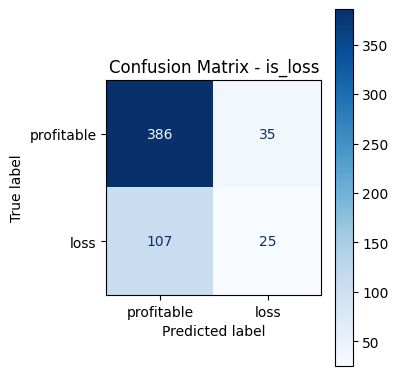

In [71]:
def fit_and_evaluate_regressor(X_tr, y_tr, X_te, y_te):
    """Fit RF regressor and print test-set metrics."""
    model = RandomForestRegressor(n_estimators=300, max_depth=12, random_state=42, n_jobs=-1)
    model.fit(X_tr, y_tr)
    preds = model.predict(X_te)

    print("Regression (profit €)")
    print(f"\tR²:  {r2_score(y_te, preds):.3f}")
    print(f"\tMAE: {mean_absolute_error(y_te, preds):.0f}€")
    return model


def fit_and_evaluate_classifier(X_tr, y_tr, X_te, y_te):
    """Fit RF classifier and print test-set metrics + confusion matrix."""
    model = RandomForestClassifier(
        n_estimators=300, max_depth=12, random_state=42, n_jobs=-1, class_weight="balanced",
    )
    model.fit(X_tr, y_tr)
    preds = model.predict(X_te)
    proba = model.predict_proba(X_te)[:, 1]

    print("Classification (is_loss)")
    print(f"\tROC-AUC: {roc_auc_score(y_te, proba):.3f}")
    print(classification_report(y_te, preds, target_names=["profitable", "loss"]))

    _, ax = plt.subplots(figsize=(4, 4))
    ConfusionMatrixDisplay.from_predictions(y_te, preds, display_labels=["profitable", "loss"], ax=ax, cmap="Blues")
    ax.set_title("Confusion Matrix - is_loss")
    plt.tight_layout()
    plt.show()
    return model


rf_reg = fit_and_evaluate_regressor(X_train, y_reg_train, X_test, y_reg_test)
rf_clf = fit_and_evaluate_classifier(X_train, y_clf_train, X_test, y_clf_test)

## SHAP Analysis

TreeExplainer gives exact Shapley values for tree ensembles. All plots use **test data** so they explain generalisation behaviour.

We show:
1. **Summary (beeswarm)** - global feature importance + direction of effect
2. **Dependence plots** - how `ai_usage_pct` effect varies by `pricing_model` and `seniority`
3. **Waterfall** - single-prediction decomposition for a representative loss-making task

In [72]:
def compute_shap_values(model, X_data):
    """Compute SHAP values using TreeExplainer. Returns shap.Explanation."""
    explainer = shap.TreeExplainer(model)
    shap_values = explainer(X_data)
    return shap_values


shap_reg = compute_shap_values(rf_reg, X_test)
shap_clf = compute_shap_values(rf_clf, X_test)

# for classification, TreeExplainer returns values per class - take class 1 (loss)
if shap_clf.values.ndim == 3:
    shap_clf = shap.Explanation(
        values=shap_clf.values[:, :, 1],
        base_values=shap_clf.base_values[:, 1],
        data=shap_clf.data,
        feature_names=shap_clf.feature_names,
    )

### 1. SHAP Summary - Beeswarm plots

Each dot is one test-set prediction. Horizontal position = SHAP value (impact on prediction), colour = feature value (red = high, blue = low). Features sorted by mean |SHAP|.

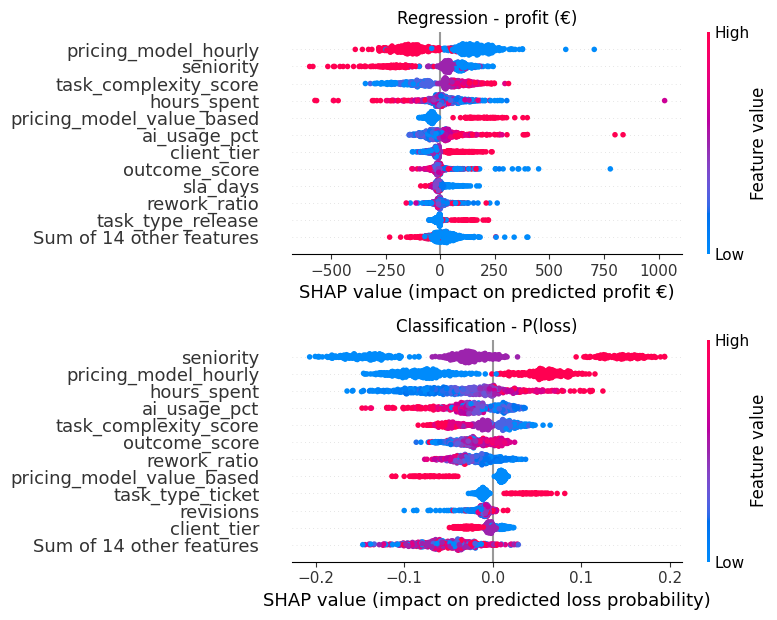

In [73]:
fig, axes = plt.subplots(2, 1, figsize=(15, 12))

plt.sca(axes[0])
shap.plots.beeswarm(shap_reg, max_display=12, show=False)
axes[0].set_title("Regression - profit (€)")
axes[0].set_xlabel("SHAP value (impact on predicted profit €)")

plt.sca(axes[1])
shap.plots.beeswarm(shap_clf, max_display=12, show=False)
axes[1].set_title("Classification - P(loss)")
axes[1].set_xlabel("SHAP value (impact on predicted loss probability)")

plt.tight_layout()
plt.show()

**How to read these plots:** each row is a feature, each dot is a single task from the test set. A dot's horizontal position shows how much that feature pushed the model's prediction up (right) or down (left) *for that specific task*. Dot colour indicates the actual value of the feature: red = high, blue = low. Features are ranked top-to-bottom by overall influence.

**Regression (profit):**
- **`pricing_model_hourly`** is the single strongest driver. The red dots (hourly = 1) cluster on the left, meaning hourly pricing systematically drags profit down, often by 200-500 euros. This aligns with the EDA finding: under hourly contracts, AI-driven efficiency savings go to the client, not the agency.
- **`seniority`** shows a clear directional split: higher seniority (red) pushes profit up, lower seniority (blue) pushes it down. Senior staff generate more profitable tasks on average.
- **`task_complexity_score`** matters, but the spread is wide: complexity affects profit in a context-dependent way (some complex tasks are very profitable, others are not).
- **`ai_usage_pct`** ranks mid-table. Its effect is moderate and roughly symmetric: high AI usage (red) tends to nudge profit slightly up, but the effect is far weaker than pricing model or seniority. AI helps, but the business context around it matters more.

**Classification (P(loss)):**
- **`seniority`** is the top feature, but the direction is the *opposite* of regression: higher seniority (red) pushes the probability of loss **up**. This is not a contradiction: it can be interpreted as seniors that produce higher profit on average (regression), but their higher cost means that when things go wrong, they cross the loss threshold more easily. Juniors (blue) push P(loss) down because their lower cost acts as a buffer.
- **`pricing_model_hourly`** again appears near the top: hourly pricing (red) pushes P(loss) to the right, increasing loss probability.
- **`hours_spent`** ranks higher here than in regression: tasks that consume many hours (red) push P(loss) rightward, suggesting that long-running tasks are a risk signal for losses.
- **`ai_usage_pct`** shows a mild protective effect: higher AI usage (red) tends to push P(loss) slightly to the left, meaning AI-heavy tasks are somewhat less likely to lose money, but the effect is modest.
- **`outcome_score`** pushes in the expected direction: higher quality scores (red) reduce loss probability (dots shift left), while low scores (blue) increase it.

### 2. SHAP Dependence: AI usage conditioned on pricing model & seniority

These plots answer: *"Does AI's effect on profit change depending on the pricing model or seniority?"*
Colour encodes the interaction variable so clusters reveal conditional effects.

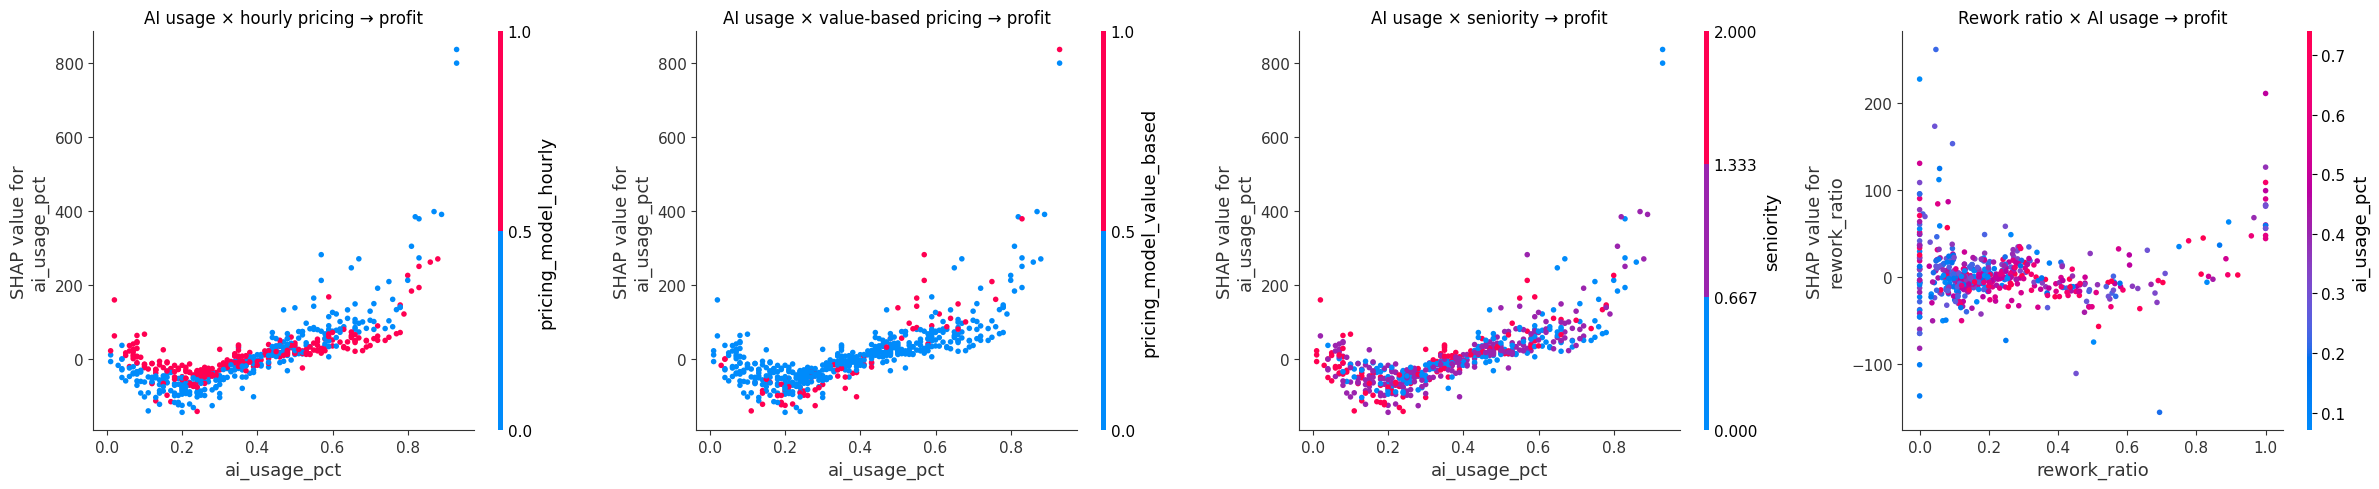

In [74]:
def shap_dependence(shap_values, feature, interaction, X_data, ax, title=None):
    """SHAP dependence plot coloured by an interaction variable."""
    shap.dependence_plot(
        feature, shap_values.values, X_data,
        interaction_index=interaction, ax=ax, show=False,
    )
    if title:
        ax.set_title(title)


dependence_pairs = [
    ("ai_usage_pct", "pricing_model_hourly", "AI usage × hourly pricing → profit"),
    ("ai_usage_pct", "pricing_model_value_based", "AI usage × value-based pricing → profit"),
    ("ai_usage_pct", "seniority", "AI usage × seniority → profit"),
    ("rework_ratio", "ai_usage_pct", "Rework ratio × AI usage → profit"),
]

fig, axes = plt.subplots(1, len(dependence_pairs), figsize=(6 * len(dependence_pairs), 5))
for ax, (feat, interact, title) in zip(axes, dependence_pairs):
    shap_dependence(shap_reg, feat, interact, X_test, ax, title)

plt.tight_layout()
plt.show()

Partial dependence plots to investigate in a deeper way the effects of interactions on the variables that have the highest shapley values. They show for one feature at a time the raw feature value on the x-value, the shapley value for that same feature in the y-axis and color based off it to reveal the interaction pattern.

They basically ask:
> _How does feature x affect profit and does that effect change depending on another variable?_

The global pattern reveals that AI usage has a **highly non linear effect on profit**. Three plots show basically the same shape where
- at very low AI usage SHAP values are around zero/mildly negative
- at moderate AI usage $\approx 0.15 - 30$, the contribution value becomes mostly negative
- at high AI usage the contribution becomes clearly positive

So the pattern is a **U shaped** or **convex effect** with strong gains when AI usage is sufficiently high.

A plausible interpretation could be that the model views AI as beneficial only once it is used deeply enough to change delivery efficiency.

The fourth plot is the only different one, showing the effect of rework ratio, modulated by AI usage.
The cloud shows:
- for small rework ratios, SHAP values are centered near zero but with high variance
- as rework ratio increases into moderate levels, contributions are mostly negative
- at very high rework ratios there are a few positive outliers, but those are sparse and should not dominate the interpretation

So the main message is that more rework implies a lower predicted profit.

### 3. Waterfall: Decomposing a single loss-making prediction

Picks the test-set task with the largest predicted loss and shows how each feature pushed the prediction away from the baseline (average profit).

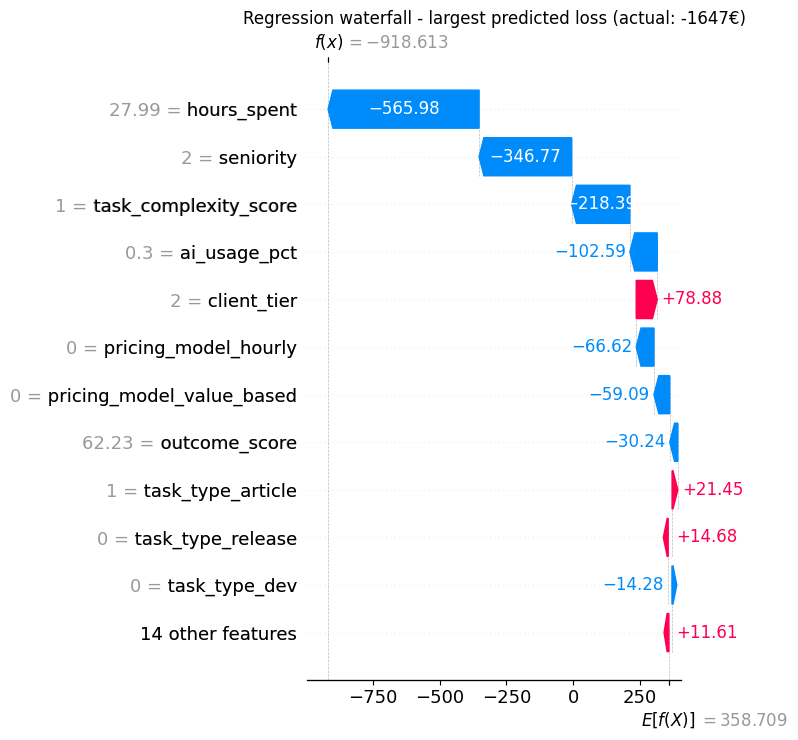

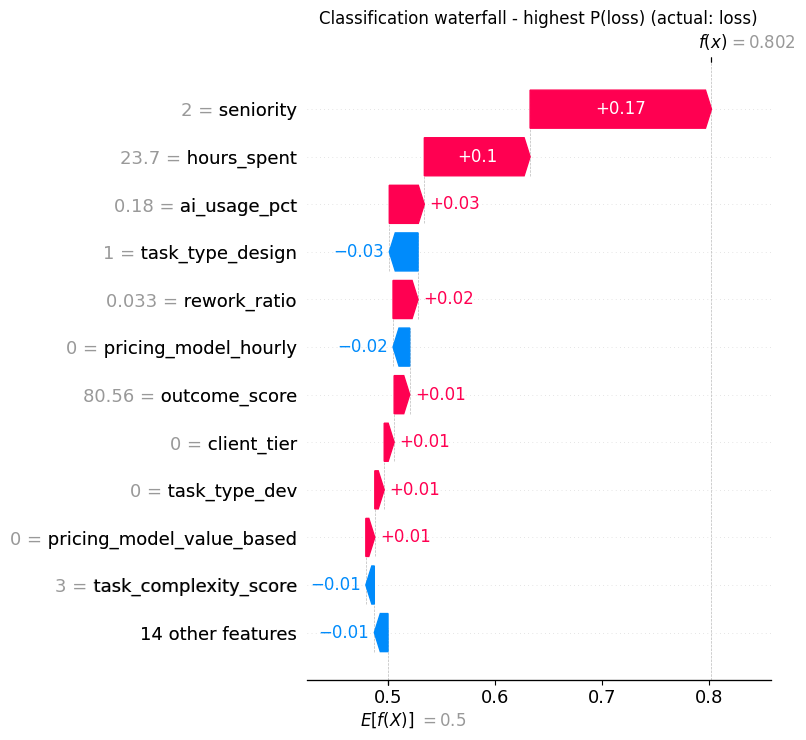

In [75]:
def plot_waterfall(shap_values, idx, title, max_display=12):
    """Waterfall plot for a single observation."""
    fig = plt.figure(figsize=(10, 6))
    shap.plots.waterfall(shap_values[idx], max_display=max_display, show=False)
    plt.title(title)
    plt.tight_layout()
    plt.show()


# regression: worst predicted loss
worst_idx = int(np.argmin(rf_reg.predict(X_test)))
plot_waterfall(
    shap_reg, worst_idx,
    f"Regression waterfall - largest predicted loss (actual: {y_reg_test.iloc[worst_idx]:.0f}€)",
)

# classification: highest predicted P(loss)
highest_loss_prob_idx = int(np.argmax(rf_clf.predict_proba(X_test)[:, 1]))
plot_waterfall(
    shap_clf, highest_loss_prob_idx,
    f"Classification waterfall - highest P(loss) (actual: {'loss' if y_clf_test.iloc[highest_loss_prob_idx] else 'profitable'})",
)

Each bar shows how much a single feature pushed this specific task's prediction away from the baseline (the average prediction across all tasks). Blue bars push the prediction down, red bars push it up. The numbers on the left (e.g. `27.99 = hours_spent`) are the actual feature values for this task.

**Regression waterfall (actual loss: -1,647 euros):**
The story: a senior contributor spent 28 hours on a trivially simple task with moderate AI assistance and no value-based pricing to capture the value. This is a resource allocation failure, not an AI failure.

**Classification waterfall (actual: loss, predicted P(loss) = 0.80):**

The baseline is 0.50 (equal odds). The model pushes this to 0.80 (high confidence of loss):
Both models converge on the same diagnosis for loss-making tasks: the combination of senior contributors, high hours, and low-complexity or low-AI-usage tasks is where losses concentrate. The pricing model matters, but for these extreme cases the resource mismatch is the primary cause.

---

## OLS Regression

The Random Forest gave us a diagnostic layer via SHAP. Now we build the interpretable model that answers the business questions directly.

**Why OLS and not just the RF?**
OLS reports coefficients with standard errors and confidence intervals, it tells you not just that a feature matters, but *by how much*, *in which direction*, and *how certain we are*. That is what a business deliverable requires.

**Modelling strategy:**
1. **Baseline** - `profit` regressed on all controls, no interactions. Establishes the main effects and checks which variables survive with statistical significance.
2. **Interaction models** - add terms one at a time: `ai_usage_pct × pricing_model`, `ai_usage_pct × seniority`, `ai_usage_pct × task_complexity_score`. Each interaction tests whether the effect of AI changes across a subgroup.
3. **Model selection** - compare specifications via AIC/BIC to keep only the interactions that genuinely improve fit without overfitting.

In [ ]:
ORDINAL_MAPS = {
    col: {cat: i for i, cat in enumerate(cats)}
    for col, cats in zip(ORDINAL_COLS, ORDINAL_CATEGORIES)
}

def prepare_ols_frame(X_raw, y):
    """
    Build a regression-ready dataframe from the raw feature frame.
    Ordinal columns are mapped to integers; nominal columns stay as strings
    so the formula API handles dummy creation via C().
    """
    df_ols = X_raw.copy()
    df_ols["profit"] = y.values
    for col, mapping in ORDINAL_MAPS.items():
        df_ols[col] = df_ols[col].map(mapping)
    return df_ols.dropna()

df_ols = prepare_ols_frame(X_raw, y_reg)
print(f"OLS dataframe: {df_ols.shape[0]} rows × {df_ols.shape[1]} columns")

OLS dataframe: 2765 rows × 18 columns


### Baseline OLS 

All controls included, no interaction terms. Reference categories: `pricing_model = fixed`, `task_type = ad`, `team = Content`.

In [77]:
BASELINE_FORMULA = """
profit ~ ai_usage_pct
       + hours_spent
       + rework_ratio
       + task_complexity_score
       + brief_quality_score
       + outcome_score
       + errors
       + revisions
       + sla_days
       + scope_change_flag
       + seniority
       + deadline_pressure
       + client_tier
       + C(pricing_model, Treatment(reference='fixed'))
       + C(task_type,     Treatment(reference='ad'))
       + C(team,          Treatment(reference='Content'))
"""

ols_baseline = smf.ols(BASELINE_FORMULA, data=df_ols).fit(cov_type="HC3")
print(ols_baseline.summary())

                            OLS Regression Results                            
Dep. Variable:                 profit   R-squared:                       0.115
Model:                            OLS   Adj. R-squared:                  0.108
Method:                 Least Squares   F-statistic:                     19.59
Date:                Wed, 08 Apr 2026   Prob (F-statistic):           3.61e-77
Time:                        16:43:48   Log-Likelihood:                -22565.
No. Observations:                2765   AIC:                         4.518e+04
Df Residuals:                    2740   BIC:                         4.533e+04
Df Model:                          24                                         
Covariance Type:                  HC3                                         
                                                                    coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------

#### Baseline results

**Model fit:** R² = 0.115, Adj R² = 0.108. The model explains ~11% of the variance in profit - consistent with the RF result. Profit at the task level is noisy; the model is not a prediction tool but a mechanism detector. The F-statistic (19.6, p < 0.001) confirms the variables are jointly significant.

Robust standard errors (HC3) are used throughout to guard against heteroscedasticity in the heavily right-skewed profit distribution.

---

**Significant findings (p < 0.05):**

- **Pricing model is the biggest lever.** Compared to a fixed-price contract, an hourly contract earns **€254 less profit** on an identical task - same team, same complexity, same AI usage. When AI makes the team faster on hourly, the client just pays fewer hours and keeps the saving. A value-based contract does the opposite: it earns **€286 more** than fixed, because the price is set by the outcome's worth, not the time spent. Fixing the contract type is worth more than any other single action.

- **AI usage helps, but moderately.** Going from 0% to 100% AI on a task adds **~€222 profit**. In practice: moving from 25% to 75% AI adds roughly **€111**. The effect is real (p = 0.015) but smaller than the pricing model effect. AI helps - but the wrong contract type erases the benefit entirely.

- **Complex tasks are more profitable.** Each step up the complexity scale (1 to 5) adds **€111 to profit**. Complex tasks justify higher rates and carry more margin. A complexity-4 task is expected to earn €222 more than a complexity-2 task, everything else equal.

- **Higher client tier means more profit.** Each tier level up adds **€114**. Better clients pay better rates or bring larger scope - both improve margin.

- **Seniority costs margin, not adds it.** Each seniority level reduces expected profit by **€173**, after controlling for hours, complexity, and pricing. Seniors cost more. If that cost is not recovered through a higher rate or more complex task, it compresses margin. A senior doing the same simple task as a junior at the same rate is expected to generate €173 less profit - not because they do worse work, but because they are more expensive. Assigning senior staff to simple tasks at standard rates is the clearest margin killer in this dataset.

- **Every extra hour costs €5 in profit.** A task that runs 20 hours over budget loses €100 in margin from the overrun alone, before considering any other effect.

- **Most task types outperform ads.** Dev (+€191), report (+€205), design (+€157), and article (+€153) all generate meaningfully more profit than ad tasks. Tickets are the weakest type (negative coefficient, not significant).

---

**What is not significant:**

`rework_ratio`, `errors`, `revisions`, `outcome_score`, `brief_quality_score`, `scope_change_flag`, `deadline_pressure`, `sla_days`, all team dummies.

Quality metrics (errors, rework, revisions) disappear once hours are controlled for. The mechanism is: errors cause rework → rework causes extra hours → extra hours reduce profit. The `hours_spent` variable already absorbs the financial damage from quality problems, leaving nothing left for errors or revisions to explain independently.


### Interaction 1 - `ai_usage_pct × pricing_model`

Does AI's effect on profit depend on the contract type? The baseline assumed AI helps equally regardless of pricing model. This model tests that assumption.

In [ ]:
INTERACT_PRICING_FORMULA = BASELINE_FORMULA.rstrip() + """
       + ai_usage_pct:C(pricing_model, Treatment(reference='fixed'))
"""

ols_pricing = smf.ols(INTERACT_PRICING_FORMULA, data=df_ols).fit(cov_type="HC3")

print(ols_pricing.summary().tables[1])
print()
print(f"{'Model':<12} {'AIC':>10} {'BIC':>10} {'R²':>8}")
print(f"{'Baseline':<12} {ols_baseline.aic:>10.1f} {ols_baseline.bic:>10.1f} {ols_baseline.rsquared:>8.4f}")
print(f"{'+ Pricing':<12} {ols_pricing.aic:>10.1f} {ols_pricing.bic:>10.1f} {ols_pricing.rsquared:>8.4f}")

#### Results

**Model fit:** AIC drops from 45,179 to 45,158 and BIC from 45,328 to 45,318 - both improve, confirming the interaction is justified and not just adding noise. R² rises to 0.124.

**What the interaction terms say:**

The main effect of `ai_usage_pct` (now = +€551) is the effect **on fixed-price contracts specifically** (the reference category). The interaction terms tell us how much that effect shifts on other contract types:

- **`ai_usage_pct × hourly`: −€744 (p < 0.001, CI: [−1,057 to −431])**
  On hourly contracts, the AI effect is €744 lower than on fixed. Net effect on hourly: 551 − 744 = **−€193**. Going from 0% to 100% AI on an hourly contract is expected to *reduce* profit by €193. The mechanism is direct: more AI → faster delivery → fewer billable hours → less revenue. The efficiency gain goes entirely to the client.

- **`ai_usage_pct × value_based`: +€255 (p = 0.40, not significant)**
  No statistically distinguishable difference from fixed contracts. Value-based pricing already captures the outcome's worth; AI efficiency gains stay with the agency either way.

**The key finding:** AI does not have one universal effect - it has opposite effects depending on the contract. On fixed contracts, AI is worth +€551 (0→100%). On hourly contracts, AI costs −€193. The contract type determines who captures the efficiency gain.

**Business implication:** investing in AI tools for teams working predominantly on hourly accounts destroys margin. The priority action is repricing or renegotiating hourly contracts before scaling AI adoption.

### Interaction 2 - `ai_usage_pct × seniority`

Does AI help juniors and seniors equally? The baseline assumes yes. The EDA suggested seniors benefit more from AI while juniors may over-rely on it at high usage.

In [79]:
INTERACT_SENIORITY_FORMULA = BASELINE_FORMULA.rstrip() + """
       + ai_usage_pct:seniority
"""

ols_seniority = smf.ols(INTERACT_SENIORITY_FORMULA, data=df_ols).fit(cov_type="HC3")
print(ols_seniority.summary().tables[1])
print()
print(f"{'Model':<14} {'AIC':>10} {'BIC':>10} {'R²':>8}")
print(f"{'Baseline':<14} {ols_baseline.aic:>10.1f} {ols_baseline.bic:>10.1f} {ols_baseline.rsquared:>8.4f}")
print(f"{'+ Seniority':<14} {ols_seniority.aic:>10.1f} {ols_seniority.bic:>10.1f} {ols_seniority.rsquared:>8.4f}")

                                                                    coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------------------------------------------
Intercept                                                       305.8743    163.614      1.869      0.062     -14.804     626.552
C(pricing_model, Treatment(reference='fixed'))[T.hourly]       -254.7805     34.529     -7.379      0.000    -322.456    -187.105
C(pricing_model, Treatment(reference='fixed'))[T.value_based]   282.2147     58.254      4.845      0.000     168.039     396.390
C(task_type, Treatment(reference='ad'))[T.article]              150.6663     53.914      2.795      0.005      44.996     256.336
C(task_type, Treatment(reference='ad'))[T.design]               155.6815     59.732      2.606      0.009      38.608     272.755
C(task_type, Treatment(reference='ad'))[T.dev]                  191.6511     57.292      3

#### Results


**Key coefficients:**

| Term | Coefficient | p-value |
|---|---|---|
| `ai_usage_pct` (juniors, seniority=0) | −€72 | 0.53 - not significant |
| `seniority` (at ai_usage_pct=0) | −€296 | <0.001 |
| `ai_usage_pct:seniority` | **+€351** | **0.004** |

**How to read the interaction:** the main effect of `ai_usage_pct` (−€72) now applies only to juniors (seniority=0). For each seniority level up, the AI benefit increases by €351. So:

| Seniority | AI effect (0→100%) |
|---|---|
| Junior | −€72 (not significant - AI is neutral for juniors) |
| Mid | −72 + 351 = **+€279** |
| Senior | −72 + 351×2 = **+€630** |

**The finding:** AI is not a leveller - it amplifies existing skill. For senior staff, heavy AI usage is worth +€630 in profit (0→100%). For juniors, AI contributes nothing to profit after controlling for everything else. AI helps people who already know what they are doing; it does not compensate for lack of experience.

**Why juniors don't benefit:** juniors using AI heavily may produce work faster but require more revisions and rework to reach acceptable quality - the speed gain is eroded by the correction cycle. The net profit contribution is zero.

**Business implication:** AI adoption should be prioritised for senior and mid-level staff. Rolling it out uniformly across all seniority levels will show weak average returns because junior gains are negligible.

### Interaction 3 - `ai_usage_pct × task_complexity_score`

Does AI help more on complex tasks or simple ones? The EDA suggested a sweet spot at complexity 3–4, with diminishing returns at both extremes.

In [80]:
INTERACT_COMPLEXITY_FORMULA = BASELINE_FORMULA.rstrip() + """
       + ai_usage_pct:task_complexity_score
"""

ols_complexity = smf.ols(INTERACT_COMPLEXITY_FORMULA, data=df_ols).fit(cov_type="HC3")
print(ols_complexity.summary().tables[1])
print()
print(f"{'Model':<14} {'AIC':>10} {'BIC':>10} {'R²':>8}")
print(f"{'Baseline':<14} {ols_baseline.aic:>10.1f} {ols_baseline.bic:>10.1f} {ols_baseline.rsquared:>8.4f}")
print(f"{'+ Complexity':<14} {ols_complexity.aic:>10.1f} {ols_complexity.bic:>10.1f} {ols_complexity.rsquared:>8.4f}")

                                                                    coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------------------------------------------
Intercept                                                       240.6447    171.516      1.403      0.161     -95.520     576.810
C(pricing_model, Treatment(reference='fixed'))[T.hourly]       -253.8210     34.614     -7.333      0.000    -321.664    -185.978
C(pricing_model, Treatment(reference='fixed'))[T.value_based]   286.8283     58.884      4.871      0.000     171.418     402.238
C(task_type, Treatment(reference='ad'))[T.article]              154.0978     54.110      2.848      0.004      48.045     260.151
C(task_type, Treatment(reference='ad'))[T.design]               158.0326     59.788      2.643      0.008      40.851     275.214
C(task_type, Treatment(reference='ad'))[T.dev]                  191.3944     57.220      3

#### Results

**Model fit:** AIC *worsens* by 1 point (45,180 → 45,181). BIC worsens by 8 points. R² is essentially unchanged (0.1155 → 0.1156). The interaction adds no explanatory value.

**Key coefficients:**

| Term | Coefficient | p-value |
|---|---|---|
| `ai_usage_pct` (at complexity=0) | +€91 | 0.58 - not significant |
| `task_complexity_score` (at ai_usage_pct=0) | +€94 | 0.001 |
| `ai_usage_pct:task_complexity_score` | **+€45** | **0.43 - not significant** |

**The finding:** the OLS finds no statistically significant interaction between AI usage and task complexity. The EDA pattern (sweet spot at complexity 3–4) does not survive as a linear interaction after controlling for the other variables. Three possible explanations:

1. The EDA pattern was partially driven by confounders (e.g. complex tasks happen to be on better contracts or done by seniors).
2. The relationship is non-linear - a linear interaction term cannot capture a sweet spot, only a monotonic slope change. A quadratic term or spline would be needed to test this properly.
3. The sample is not large enough to detect what may be a real but small effect.

**Decision: drop this interaction.** AIC and BIC both worsen, the term is not significant, and the pattern from the EDA is better explained by the variables already in the model. The complexity main effect (+€111 per point) remains valid - complex tasks are more profitable - but there is no evidence that AI amplifies this effect.

### Model Selection - AIC/BIC Comparison

Four specifications compared: baseline, pricing interaction only, seniority interaction only, and the final model with both.

In [ ]:
FINAL_FORMULA = BASELINE_FORMULA.rstrip() + """
       + ai_usage_pct:C(pricing_model, Treatment(reference='fixed'))
       + ai_usage_pct:seniority
"""

ols_final = smf.ols(FINAL_FORMULA, data=df_ols).fit(cov_type="HC3")

models = {
    "Baseline":          ols_baseline,
    "+ Pricing ixn":     ols_pricing,
    "+ Seniority ixn":   ols_seniority,
    "Final (both ixns)": ols_final,
}

print(f"{'Model':<22} {'AIC':>10} {'BIC':>10} {'R²':>8}  {'ΔAIC vs baseline':>18}")
for name, m in models.items():
    delta = m.aic - ols_baseline.aic
    print(f"{name:<22} {m.aic:>10.1f} {m.bic:>10.1f} {m.rsquared:>8.4f}  {delta:>+18.1f}")

| Model | AIC | BIC | R² | ΔAIC |
|---|---|---|---|---|
| Baseline | 45,179 | 45,328 | 0.1155 | - |
| + Pricing interaction | 45,158 | 45,318 | 0.1237 | −22 |
| + Seniority interaction | 45,172 | 45,326 | 0.1187 | −8 |
| **Final (both)** | **45,150** | **45,316** | **0.1266** | **−29** |

Both interactions improve AIC and BIC individually, and combining them gives the best fit on both criteria. The final model is selected.

**Note on `ai_usage_pct × value_based`:** the pricing interaction term is added as `C(pricing_model)`, which brings in both the hourly and value_based interactions. The value_based term is non-significant in both the standalone interaction model (p = 0.40) and the final model (p = 0.43). It is carried along as part of the categorical encoding, not as a selected finding. The actionable result is the hourly interaction only.

---

## OLS Conclusions

**1. Contract type is the biggest lever, not AI usage.**
Hourly contracts structurally prevent the agency from capturing AI efficiency gains, the client just pays fewer hours. Fixed contracts let the agency keep the saving. The pricing model effect (±€254) outweighs the average AI effect (€222) at full adoption.

**2. AI helps, but only on the right contracts.**
On fixed-price contracts, going from 0% to 100% AI usage adds €551 in profit. On hourly contracts, the same increase *costs* €193. Rolling out AI uniformly across contract types will show weak average returns because gains on fixed are cancelled by losses on hourly.

**3. AI amplifies skill: it does not replace it.**
Senior staff see +€630 profit from full AI adoption. Juniors see no statistically significant benefit. The mechanism is likely that juniors incur rework cycles that erase the speed gain. AI investment should be prioritised where experience is already in place.

**4. Complex tasks and better clients drive margin.**
Each complexity point adds €111 in profit; each client tier level adds €114. These are the two cleanest controls in the model, independent of AI usage and contract type.

**Priority actions:**
- Renegotiate or reprice hourly accounts before scaling AI tooling
- Target AI adoption for senior and mid-level staff first
- Route complex, high-tier client work to AI-enabled fixed-price contracts